In [2]:
import statsmodels.api as sm
import numpy as np

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# plt.rc("font", family = "Malgun Gothic")
# sns.set(font="Malgun Gothic", 
# rc={"axes.unicode_minus":False}, style='white')

# 한글 폰트 설정 (Mac)
plt.rc('font', family='AppleGothic')
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [7]:
gangwon_industry = pd.read_csv('./data/merge_file_gangwon/산업용_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_industry = gangwon_industry[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량']]
gangwon_industry.info()

<class 'pandas.DataFrame'>
RangeIndex: 1077 entries, 0 to 1076
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   지점                  1077 non-null   int64  
 1   지점명                 1077 non-null   str    
 2   일시                  1077 non-null   str    
 3   평균기온(°C)            1077 non-null   float64
 4   평균현지기압(hPa)         1077 non-null   float64
 5   평균해면기압(hPa)         1077 non-null   float64
 6   평균수증기압(hPa)         1077 non-null   float64
 7   평균상대습도(%)           1077 non-null   float64
 8   월합강수량(00~24h만)(mm)  1077 non-null   float64
 9   평균풍속(m/s)           1077 non-null   float64
 10  일조율(%)              1077 non-null   float64
 11  최심적설(cm)            1077 non-null   float64
 12  평균지면온도(°C)          1077 non-null   float64
 13  years               1077 non-null   int64  
 14  month               1077 non-null   int64  
 15  시도                  1077 non-null   str    
 16  시군구              

In [28]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. 범주형 변수 변환 (월을 더미 변수로)
# drop_first=True는 다중공선성 방지를 위해 첫 번째 달(1월)을 기준점으로 설정합니다.
df_encoded = pd.get_dummies(gangwon_industry, columns=['month'], drop_first=True, dtype=int)

# 2. 독립변수 리스트 업데이트 (기존 x + 새로 생긴 월 더미 변수들)
month_cols = [col for col in df_encoded.columns if 'month' in col]
# x_cols = ['평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', 
#           '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', 
#           '최심적설(cm)', '평균지면온도(°C)', 'years'] + month_cols
x_cols = [ '평균기온(°C)', '평균상대습도(%)', '평균현지기압(hPa)', 
    '평균풍속(m/s)', '일조율(%)', 'years'] + month_cols


# 3. 수치형 변수 표준화 (월 더미 변수는 제외하고 실행)
# numeric_cols = ['평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', 
#                 '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', 
#                 '최심적설(cm)', '평균지면온도(°C)', 'years']
numeric_cols = ['평균기온(°C)', '평균상대습도(%)', '평균현지기압(hPa)', 
    '평균풍속(m/s)', '일조율(%)', 'years']
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# 4. 비선형성(제곱항) 추가
df_encoded['평균기온_sq'] = df_encoded['평균기온(°C)']**2

# 5. 모델 설계 및 적합
X = sm.add_constant(df_encoded[x_cols + ['평균기온_sq']])
y = df_encoded['전력량']

df_encoded = pd.get_dummies(gangwon_industry, columns=['month'], drop_first=True, dtype=int)




# 전력 데이터의 특성에 맞춰 Gamma 분포 사용
model = sm.GLM(y, X, family=sm.families.Gamma(link=sm.families.links.log())).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    전력량   No. Observations:                 1077
Model:                            GLM   Df Residuals:                     1058
Model Family:                   Gamma   Df Model:                           18
Link Function:                    log   Scale:                          1.2062
Method:                          IRLS   Log-Likelihood:                -19964.
Date:                Sun, 01 Feb 2026   Deviance:                       1473.2
Time:                        15:52:11   Pearson chi2:                 1.28e+03
No. Iterations:                    57   Pseudo R-squ. (CS):             0.1627
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          20.2117      0.352     57.398      

/Users/jaehoon/mambaforge/envs/pystudy_env/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


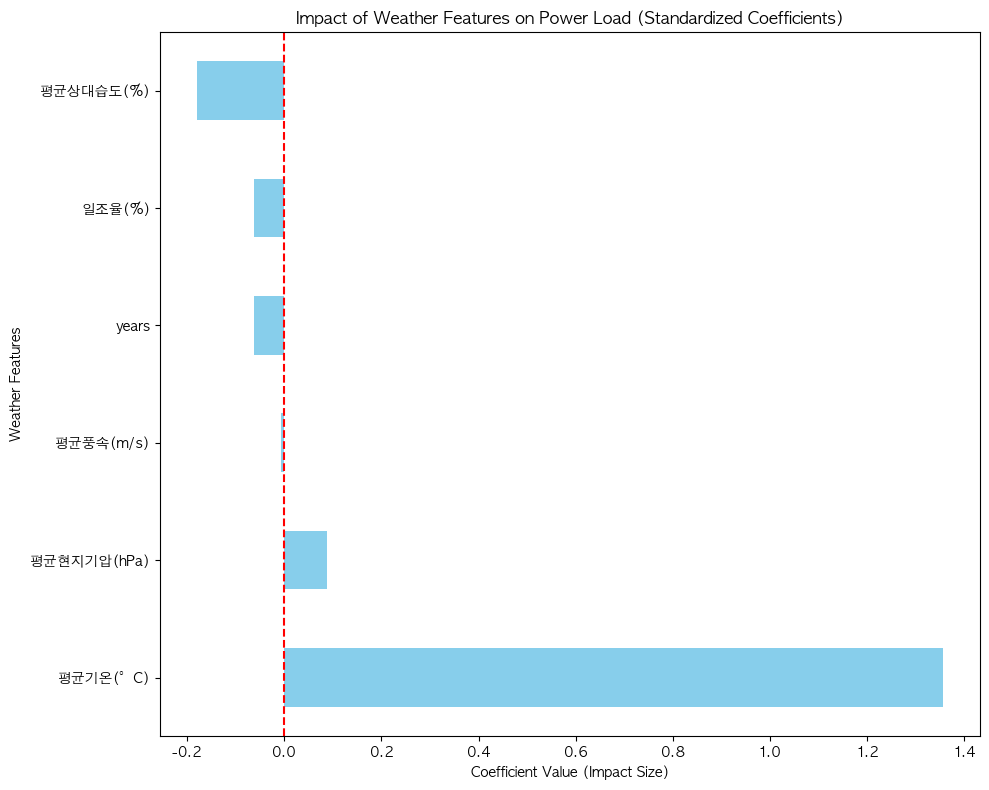

In [29]:
# 상수항과 월별 더미 변수를 제외한 주요 날씨 변수만 추출
weather_impact = model.params.drop(['const'] + month_cols + ['평균기온_sq'])
weather_impact = weather_impact.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
weather_impact.plot(kind='barh', color='skyblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Impact of Weather Features on Power Load (Standardized Coefficients)')
plt.xlabel('Coefficient Value (Impact Size)')
plt.ylabel('Weather Features')
plt.tight_layout()
plt.show()

In [30]:
print(model.pseudo_rsquared())
# Statsmodels의 GLM 객체는 일반적인 회귀 모델의 \(R^{2}\) 대신, McFadden의 Pseudo R-squared 등을 제공
# 0.2 ~ 0.4 사이: McFadden의 기준에 따르면, 
# 이 범위의 값은 모델이 데이터를 매우 훌륭하게 설명(Excellent fit)하고 있음을 의미합니다. 
# 일반 회귀의 0.6~0.8 정도의 성능으로 체감하셔도 무방합니다.

0.16268299152453625
